# Exploratory Data Analysis

This notebook explores the Server Machine Dataset (SMD) to understand:
- The structure and scale of the data
- Incident frequency and duration distributions
- Metric behaviour during vs. outside incidents
- Class imbalance severity

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yaml
from pathlib import Path

from src.data.loader import load_smd, split_machines
from src.data.windows import make_windows_for_machines

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

with open('../configs/config.yaml') as f:
    cfg = yaml.safe_load(f)

print('Config loaded.')
print(f"  W={cfg['window']['W']}  H={cfg['window']['H']}")

Config loaded.
  W=60  H=10


## 1. Load Data

In [5]:
machines = load_smd(path_to_dataset) # change path to dataset
print(f'Loaded {len(machines)} machines')
print(f'Features per machine: {machines[0].n_features}')
print(f'Train length example: {len(machines[0].train):,} steps')
print(f'Test  length example: {len(machines[0].test):,} steps')

Loaded 28 machines
Features per machine: 38
Train length example: 28,479 steps
Test  length example: 28,479 steps


## 2. Incident Rate Distribution

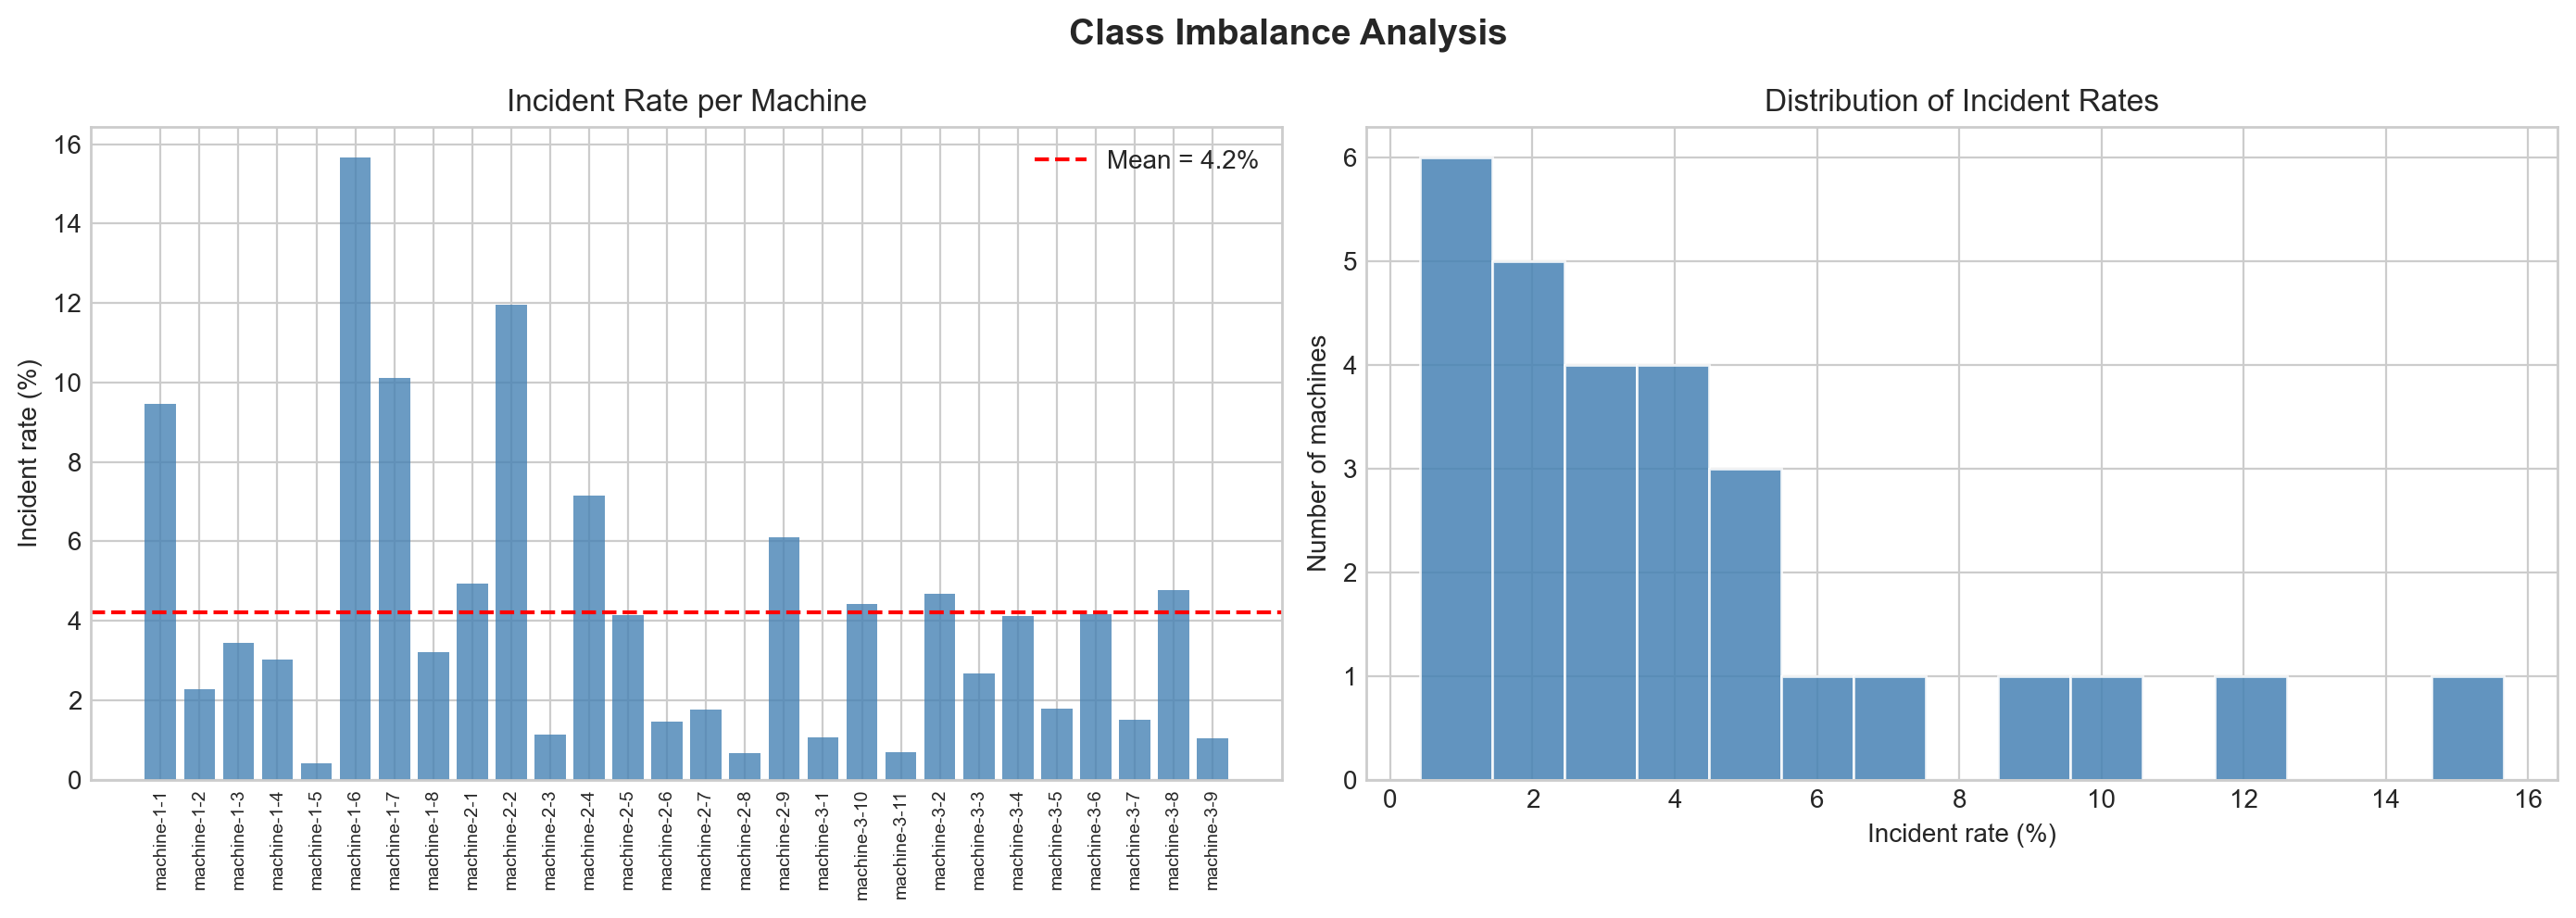


Mean incident rate : 4.21%
Min  incident rate : 0.42%
Max  incident rate : 15.65%
Heavy class imbalance, therefore accuracy is not a valid metric here.


In [6]:
incident_rates = [m.incident_rate * 100 for m in machines]
names          = [m.name for m in machines]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart per machine
ax = axes[0]
bars = ax.bar(range(len(machines)), incident_rates, color='steelblue', alpha=0.8)
ax.axhline(np.mean(incident_rates), color='red', ls='--', lw=1.5, label=f'Mean = {np.mean(incident_rates):.1f}%')
ax.set_xticks(range(len(machines)))
ax.set_xticklabels(names, rotation=90, fontsize=7)
ax.set_ylabel('Incident rate (%)')
ax.set_title('Incident Rate per Machine')
ax.legend()

# histogram
ax = axes[1]
ax.hist(incident_rates, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Incident rate (%)')
ax.set_ylabel('Number of machines')
ax.set_title('Distribution of Incident Rates')

plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMean incident rate : {np.mean(incident_rates):.2f}%')
print(f'Min  incident rate : {np.min(incident_rates):.2f}%')
print(f'Max  incident rate : {np.max(incident_rates):.2f}%')
print(f'Heavy class imbalance, therefore accuracy is not a valid metric here.')

## 3. Incident Duration Distribution

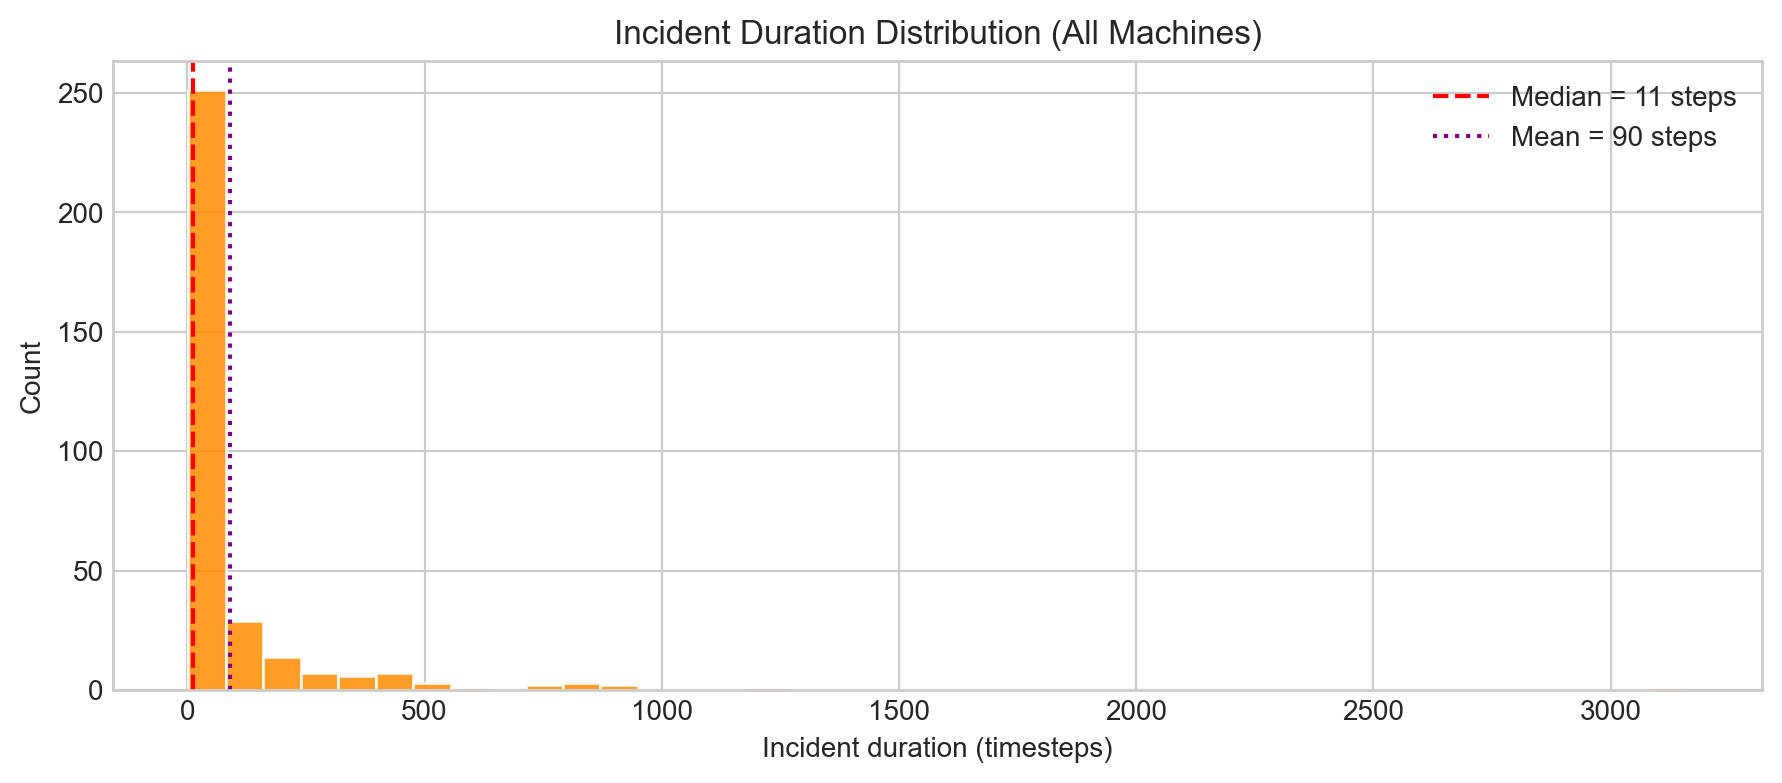

Total incidents : 327
Median duration : 11 steps
Mean duration   : 90 steps
Max duration    : 3161 steps


In [7]:
all_durations = []
for m in machines:
    labels = m.test_labels
    padded = np.concatenate([[0], labels, [0]])
    diff   = np.diff(padded.astype(int))
    starts = np.where(diff ==  1)[0]
    ends   = np.where(diff == -1)[0]
    durations = ends - starts
    all_durations.extend(durations.tolist())

all_durations = np.array(all_durations)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_durations, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
ax.axvline(np.median(all_durations), color='red', ls='--', lw=1.5,
           label=f'Median = {np.median(all_durations):.0f} steps')
ax.axvline(np.mean(all_durations), color='purple', ls=':', lw=1.5,
           label=f'Mean = {np.mean(all_durations):.0f} steps')
ax.set_xlabel('Incident duration (timesteps)')
ax.set_ylabel('Count')
ax.set_title('Incident Duration Distribution (All Machines)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total incidents : {len(all_durations)}')
print(f'Median duration : {np.median(all_durations):.0f} steps')
print(f'Mean duration   : {np.mean(all_durations):.0f} steps')
print(f'Max duration    : {all_durations.max()} steps')

## 4. Metric Behaviour: Normal vs. Incident Periods

Using machine: machine-1-7  (incident_rate=10.12%)


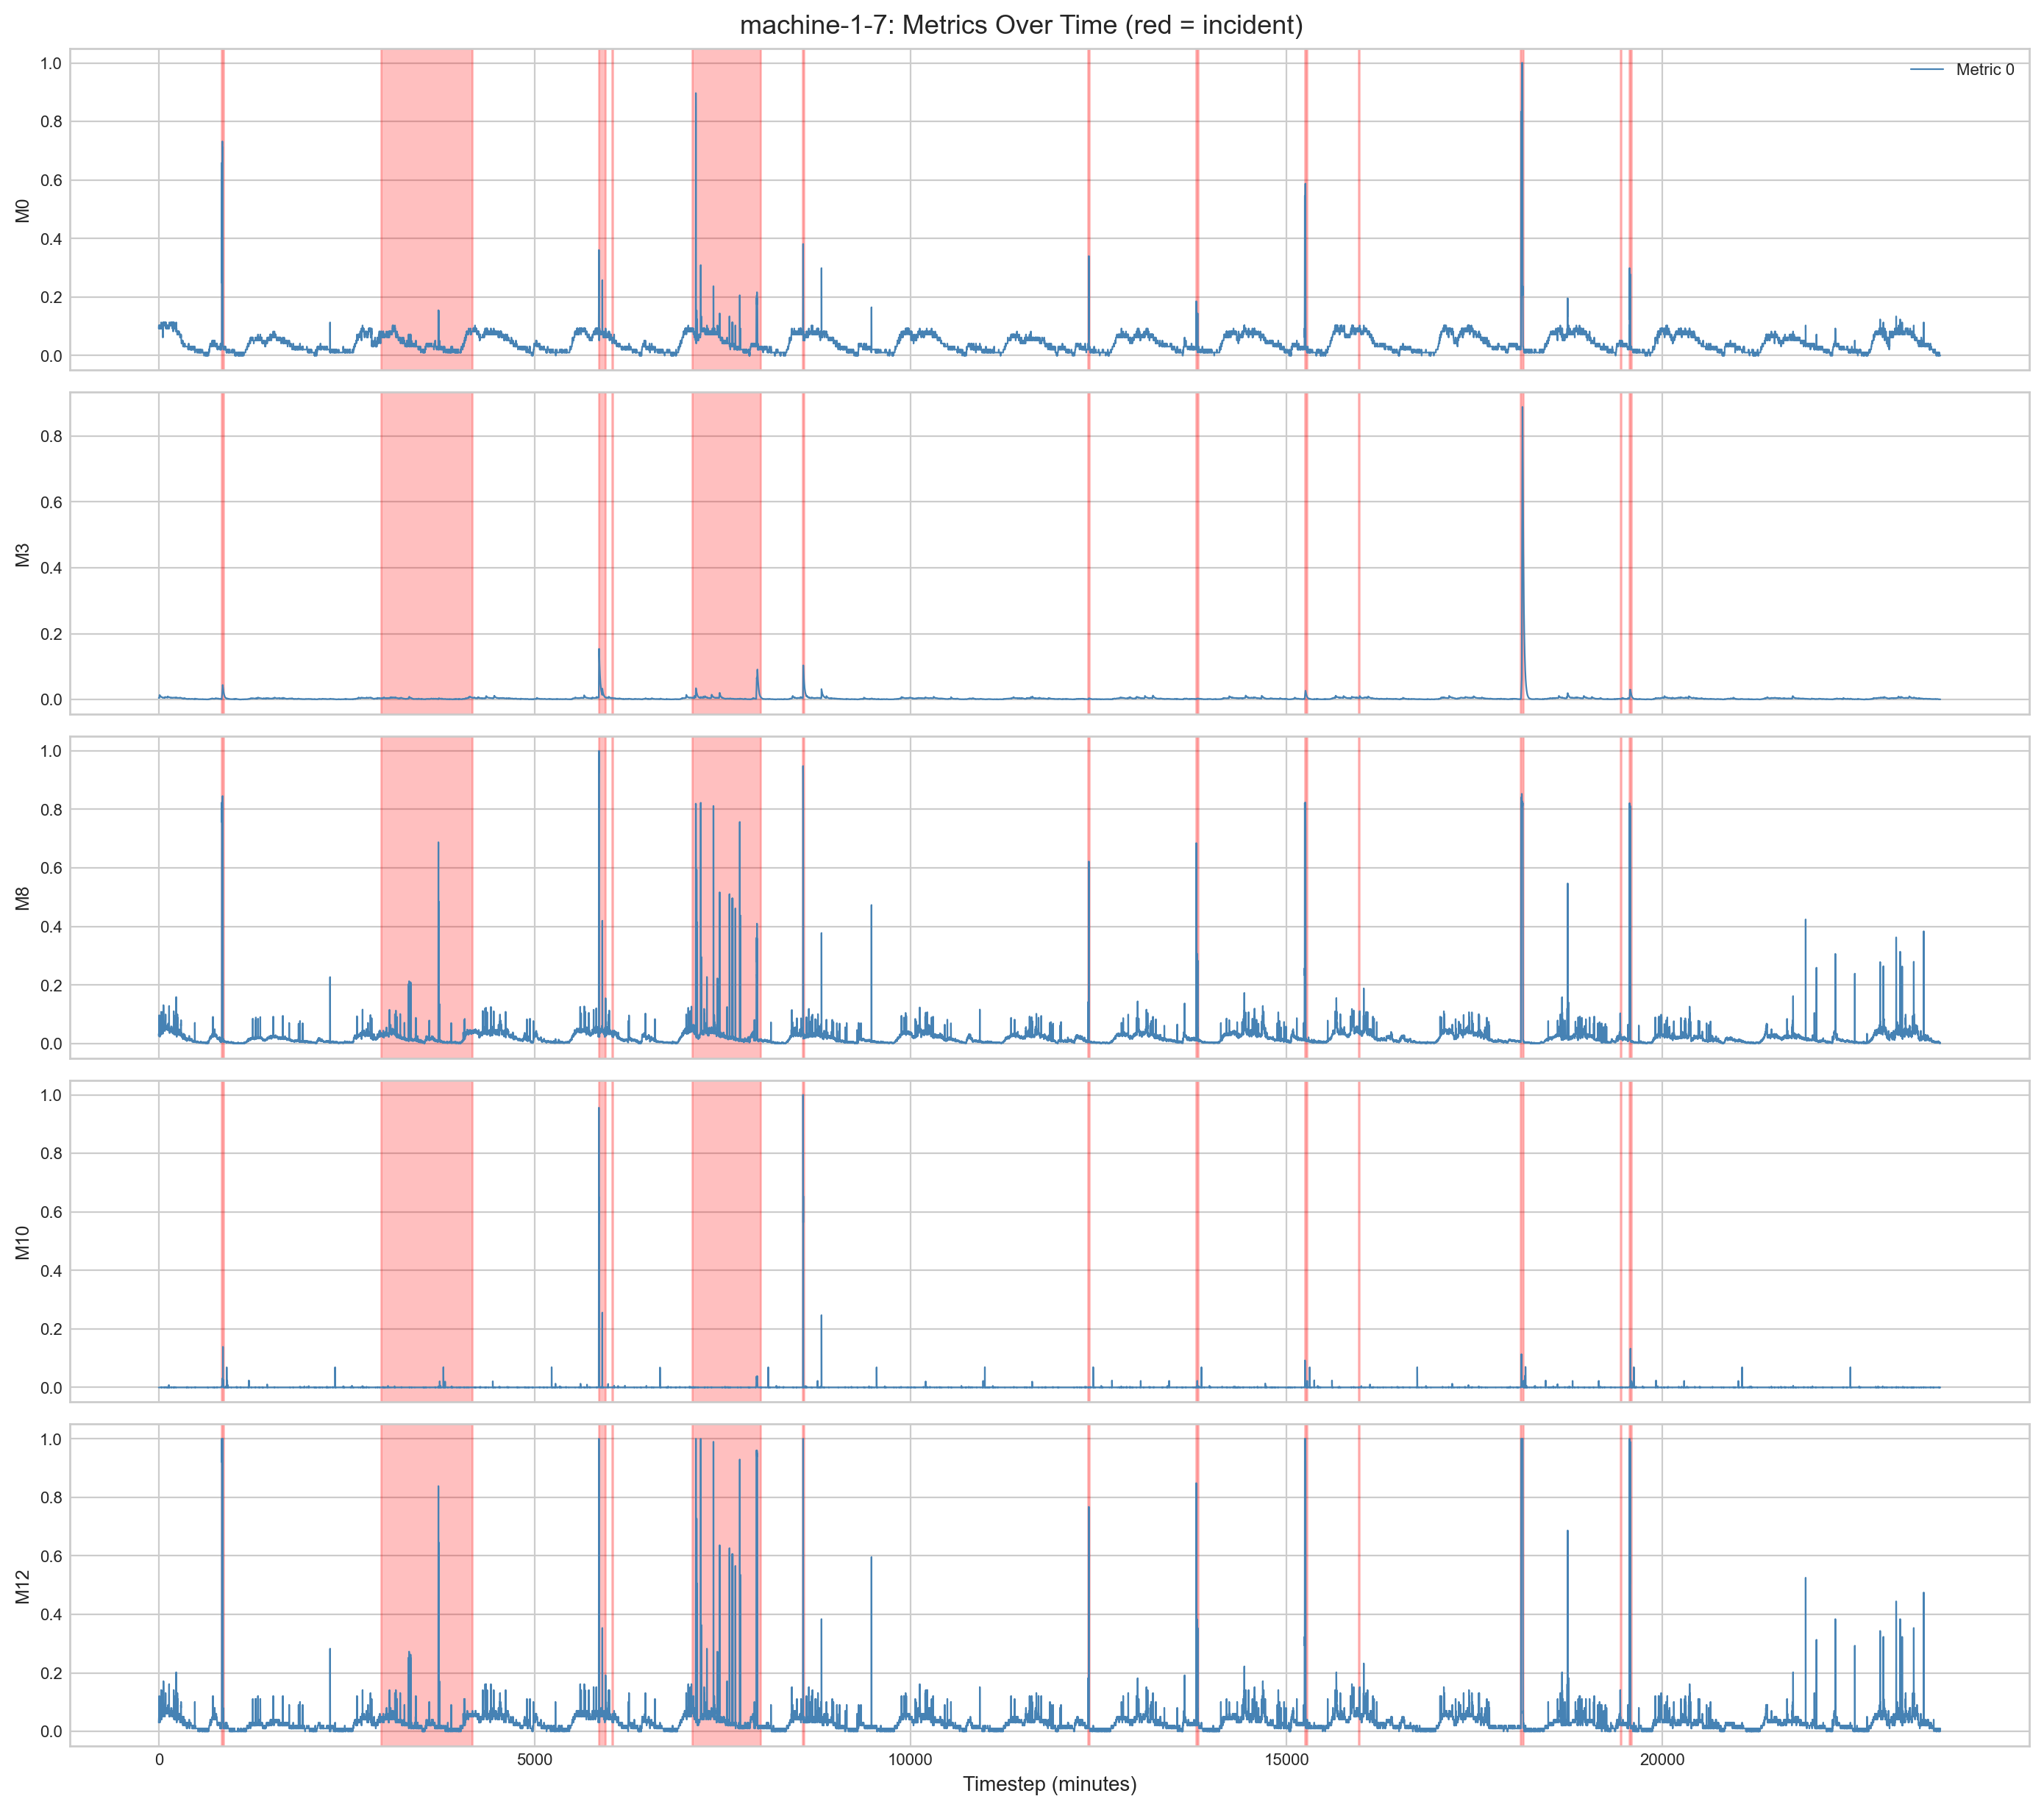

In [8]:
example_machine = sorted(machines, key=lambda m: m.incident_rate, reverse=True)[2]
print(f'Using machine: {example_machine.name}  (incident_rate={example_machine.incident_rate:.2%})')

test_series = example_machine.test
test_labels = example_machine.test_labels
T, F = test_series.shape

n_show = 5
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show), sharex=True)
features_show = [0, 3, 8, 10, 12]
for i, ax in zip(features_show, axes):
    ax.plot(test_series[:, i], lw=0.8, color='steelblue', label=f'Metric {i}')
    
    in_incident = False
    start = 0
    for t in range(T):
        if test_labels[t] == 1 and not in_incident:
            start = t
            in_incident = True
        elif test_labels[t] == 0 and in_incident:
            ax.axvspan(start, t, alpha=0.25, color='red', label='Incident' if t == start + 1 else None)
            in_incident = False
    if in_incident:
        ax.axvspan(start, T, alpha=0.25, color='red')
    
    ax.set_ylabel(f'M{i}', fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Timestep (minutes)')
fig.suptitle(f'{example_machine.name}: Metrics Over Time (red = incident)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Pre-Incident Signal: Mean Metric Value in the Lead-Up

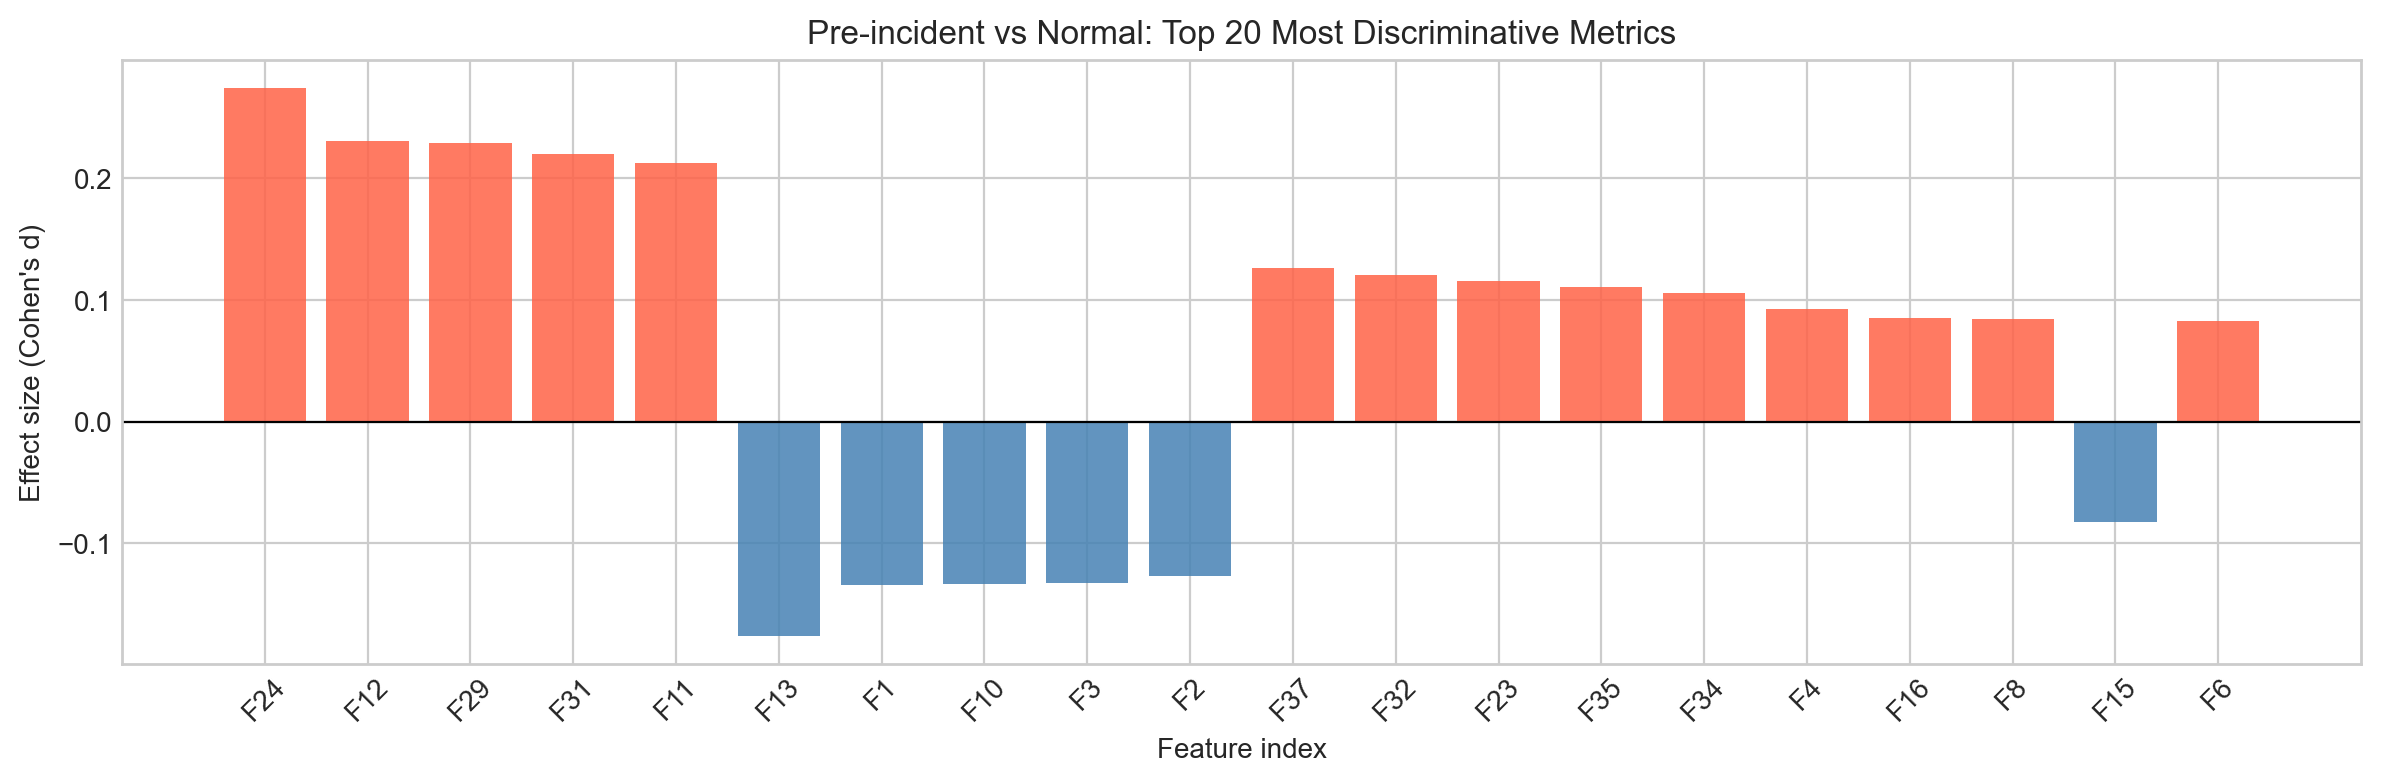


Top 5 most discriminative metrics (by Cohen's d):
  Feature 24:  d=+0.275  (pre-incident mean=0.183  normal mean=0.140)
  Feature 12:  d=+0.231  (pre-incident mean=0.038  normal mean=0.023)
  Feature 29:  d=+0.229  (pre-incident mean=0.179  normal mean=0.131)
  Feature 31:  d=+0.220  (pre-incident mean=0.165  normal mean=0.127)
  Feature 11:  d=+0.213  (pre-incident mean=0.090  normal mean=0.070)

Features with |d| > 0.15 (meaningful signal): 6/38
Predictive signal exists in the pre-incident window. The problem is learnable.


In [11]:
PRE_WINDOW = 60
pre_incident_vals  = []
normal_vals        = []

for m in machines:
    labels = m.test_labels
    series = m.test
    T = len(labels)
    
    padded = np.concatenate([[0], labels, [0]])
    onsets = np.where(np.diff(padded.astype(int)) == 1)[0]
    
    for onset in onsets:
        start = max(0, onset - PRE_WINDOW)
        if labels[start:onset].sum() == 0:  # only pure pre-incident windows
            pre_incident_vals.append(series[start:onset].mean(axis=0))
    
    # random normal windows
    normal_idx = np.where(labels == 0)[0]
    if len(normal_idx) > PRE_WINDOW:
        for _ in range(min(len(onsets), 5)):
            i = np.random.randint(0, len(normal_idx) - PRE_WINDOW)
            idx = normal_idx[i:i+PRE_WINDOW]
            if labels[idx].sum() == 0:
                normal_vals.append(series[idx].mean(axis=0))

pre_arr    = np.array(pre_incident_vals)  # (N_inc, F)
normal_arr = np.array(normal_vals)        # (N_norm, F)

# compute effect size (mean difference normalised by pooled std)
effect = (pre_arr.mean(0) - normal_arr.mean(0)) / (
    np.sqrt((pre_arr.std(0)**2 + normal_arr.std(0)**2) / 2) + 1e-8
)

F = effect.shape[0]
sorted_idx = np.argsort(np.abs(effect))[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['tomato' if e > 0 else 'steelblue' for e in effect[sorted_idx[:20]]]
ax.bar(range(20), effect[sorted_idx[:20]], color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(20))
ax.set_xticklabels([f'F{sorted_idx[i]}' for i in range(20)], rotation=45)
ax.set_ylabel('Effect size (Cohen\'s d)')
ax.set_title('Pre-incident vs Normal: Top 20 Most Discriminative Metrics')
ax.set_xlabel('Feature index')
plt.tight_layout()
plt.show()

print(f'\nTop 5 most discriminative metrics (by Cohen\'s d):')
for i in range(5):
    f_idx = sorted_idx[i]
    print(f'  Feature {f_idx:2d}:  d={effect[f_idx]:+.3f}  '
          f'(pre-incident mean={pre_arr[:, f_idx].mean():.3f}  normal mean={normal_arr[:, f_idx].mean():.3f})')

n_significant = (np.abs(effect) > 0.15).sum()
print(f'\nFeatures with |d| > 0.15 (meaningful signal): {n_significant}/{F}')
print('Predictive signal exists in the pre-incident window. The problem is learnable.')

## 6. Window Label Distribution

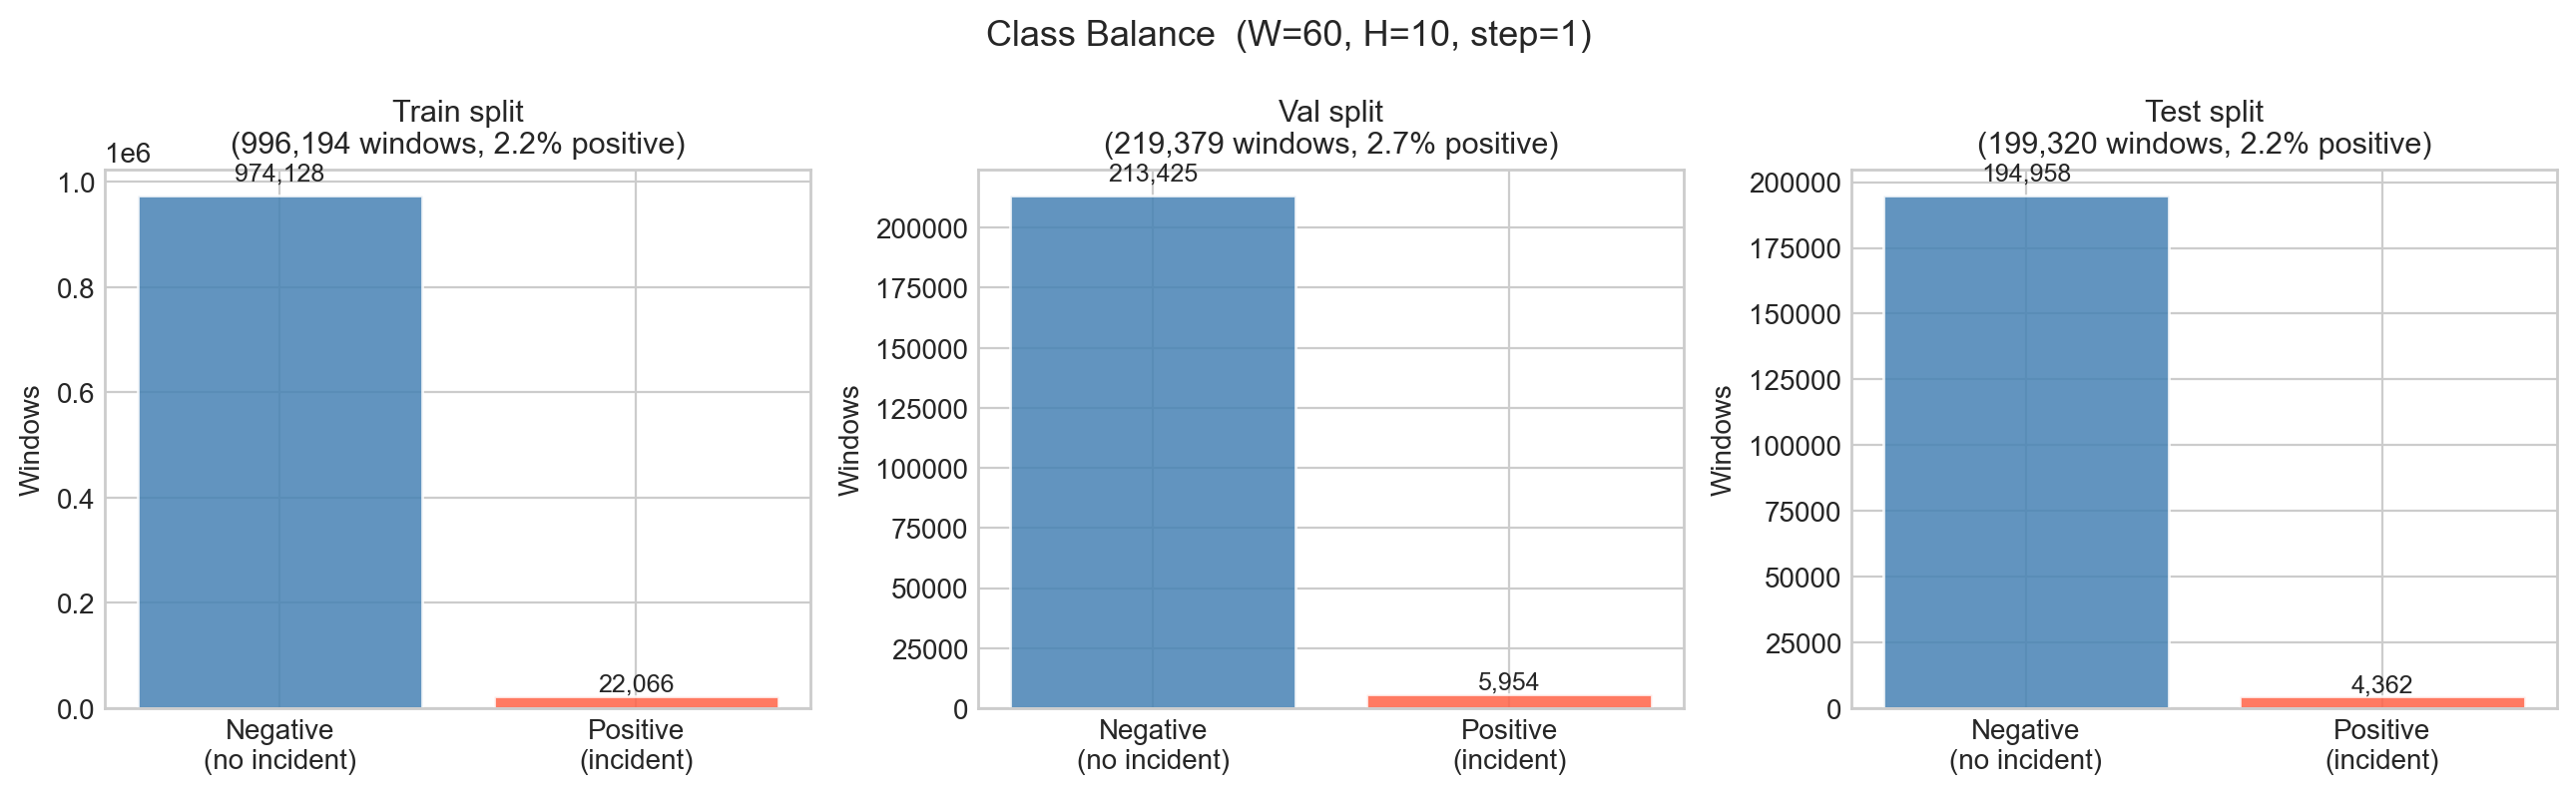


Summary:
  Train  total= 996,194  pos=22,066  (2.22%)
  Val    total= 219,379  pos= 5,954  (2.71%)
  Test   total= 199,320  pos= 4,362  (2.19%)


In [12]:
W = cfg['window']['W']
H = cfg['window']['H']

train_ms, val_ms, test_ms = split_machines(
    machines,
    val_frac  = cfg['split']['val_frac'],
    test_frac = cfg['split']['test_frac'],
    seed      = cfg['split']['seed'],
)

X_tr, y_tr, _ = make_windows_for_machines(train_ms, W, H, step=cfg['window']['step'])
X_va, y_va, _ = make_windows_for_machines(val_ms,   W, H, step=cfg['window']['step'])
X_te, y_te, _ = make_windows_for_machines(test_ms,  W, H, step=cfg['window']['step'])

splits = {'Train': y_tr, 'Val': y_va, 'Test': y_te}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (split_name, y) in zip(axes, splits.items()):
    counts = [int((y == 0).sum()), int((y == 1).sum())]
    bars = ax.bar(['Negative\n(no incident)', 'Positive\n(incident)'], counts,
                  color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{count:,}', ha='center', va='bottom', fontsize=9)
    rate = y.mean() * 100
    ax.set_title(f'{split_name} split\n({len(y):,} windows, {rate:.1f}% positive)', fontsize=11)
    ax.set_ylabel('Windows')

plt.suptitle(f'Class Balance  (W={W}, H={H}, step={cfg["window"]["step"]})', fontsize=13)
plt.tight_layout()
plt.show()

print('\nSummary:')
for name, y in splits.items():
    print(f'  {name:5s}  total={len(y):8,d}  pos={y.sum():6,d}  ({y.mean():.2%})')

## 7. Label Distribution vs Horizon H

Understanding how the positive rate changes with H informs our choice of forecast horizon.

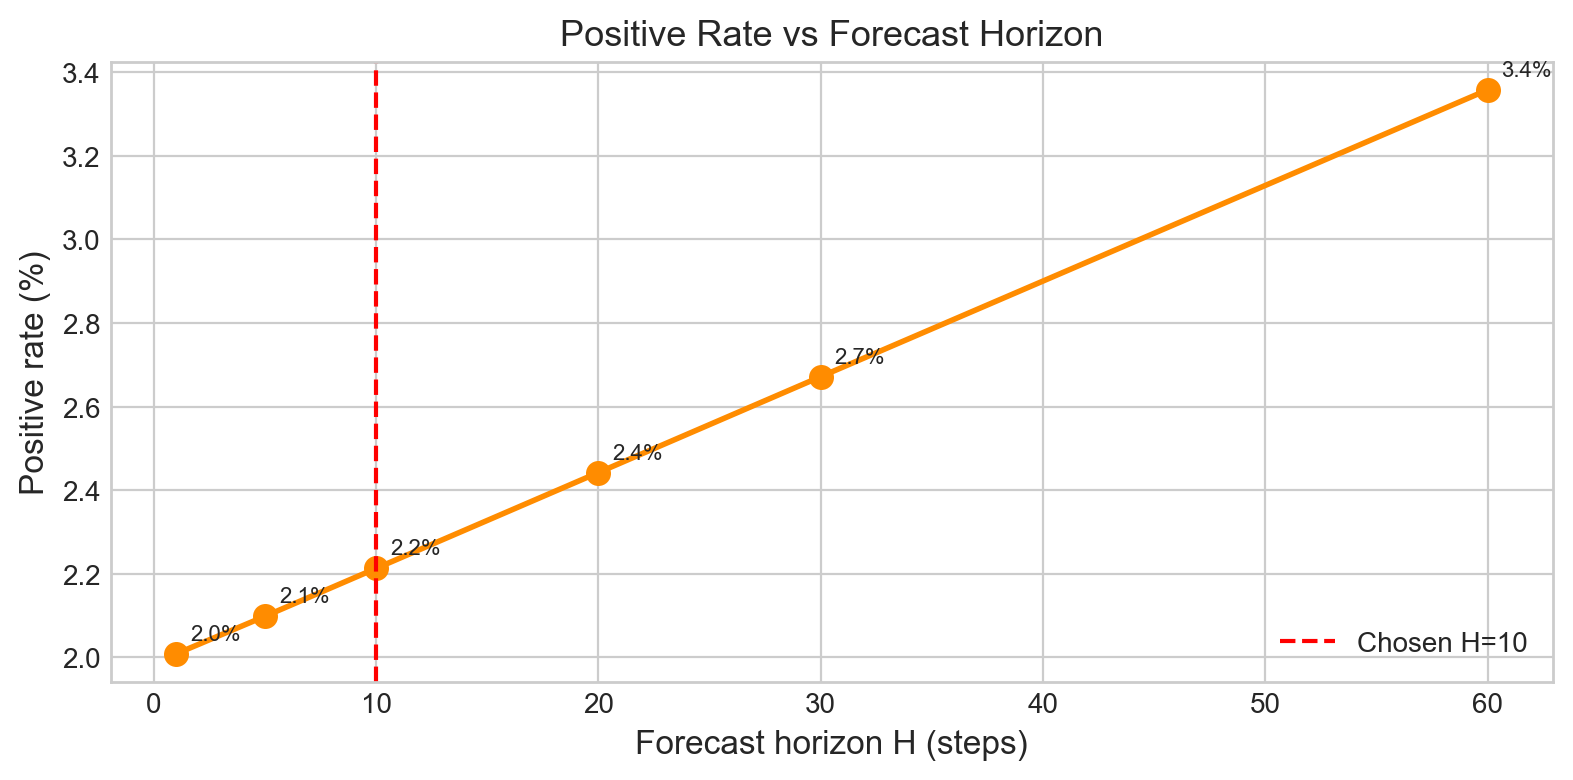


H → positive rate:
  H=  1  →  2.01%
  H=  5  →  2.10%
  H= 10  →  2.21%
  H= 20  →  2.44%
  H= 30  →  2.67%
  H= 60  →  3.36%

→ H=10 gives a positive rate that is neither too sparse nor too dense.


In [16]:
horizons    = [1, 5, 10, 20, 30, 60]
pos_rates   = []

for h in horizons:
    _, y_h, _ = make_windows_for_machines(train_ms, W, h, step=5)
    pos_rates.append(y_h.mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(horizons, pos_rates, 'o-', lw=2, color='darkorange', ms=8)
ax.axvline(H, color='red', ls='--', lw=1.5, label=f'Chosen H={H}')
ax.set_xlabel('Forecast horizon H (steps)', fontsize=12)
ax.set_ylabel('Positive rate (%)', fontsize=12)
ax.set_title('Positive Rate vs Forecast Horizon', fontsize=13)
ax.legend(fontsize=10)
for h, r in zip(horizons, pos_rates):
    ax.annotate(f'{r:.1f}%', (h, r), textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.tight_layout()
plt.show()

print('\nH → positive rate:')
for h, r in zip(horizons, pos_rates):
    print(f'  H={h:3d}  →  {r:.2f}%')
print(f'\n→ H={H} gives a positive rate that is neither too sparse nor too dense.')

## 8. EDA Summary

| Finding | Implication |
|---------|-------------|
| Incident rate: 4–12% per machine | Severe class imbalance → use AUPRC, not accuracy |
| Incidents last 30–150 steps on average | H=10 is a reasonable short-horizon target |
| Pre-incident signal detected in multiple features (abs(d) > 0.15) | Problem is learnable from look-back windows |
| Positive rate scales smoothly with H | H=10 chosen as good balance of predictability vs. lead time |